#### Project ~ Restaurant Revenue Prediction

#### 1. Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### 2. Load the dataset

In [3]:
df = pd.read_csv("D:\\INTELLIPAAT LEARNINGS COM FILES\\PYTHON\\VS Code Python\\dsenv\\revenue_prediction.csv")

In [4]:
df.head()

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715


#### 3. Exploring and Understanding Dataset

In [5]:
# Rows and Columns Count
print(f"Rows : {df.shape[0]}, Columns : {df.shape[1]}")

Rows : 100, Columns : 8


In [6]:
# Columns Names
df.columns

Index(['Id', 'Name', 'Franchise', 'Category', 'City', 'No_Of_Item',
       'Order_Placed', 'Revenue'],
      dtype='object')

**Data Explanation :**

1. Id : Restaurant Id.
2. Name : Name of the Restaurant
3. Franchise : Restaurant has Franchise or not.
4. Category : Specific type of category provided by restaurant.
5. City : City in which Restaurant is present.
6. No of Item : Different Types of Items provided by restaurant.
7. Order Placed : Order Placed by Customer to Restaurant.
8. Revenue : Total amount of income generated by restaurant.

In [7]:
# Number of unique restaurant ids
df['Id'].nunique()

100

In [8]:
# Franchise Column
df['Franchise'].value_counts()

Franchise
Yes    55
No     45
Name: count, dtype: int64

**Note :**

1. 55 Restaurants has Franchise Chain and 45 Restaurants do not have Franchise Chain. 

2. Restaurant's with Franchise chain often have :
    1. Brand Recognition
    2. Higher Customer Trust
    3. Standardized Menu
    4. Higher expected revenue.

In [9]:
df['Category'].value_counts()

Category
Varied Menu        16
Mexican            10
Pizza               9
Italian/Pizza       7
Family Style        7
Steak               7
Sandwich            7
Burger              7
Bakery Cafe         5
BBQ                 4
Seafood             4
Family Casual       3
Chicken             2
Frozen Desserts     2
Coffee Cafe         2
Sports Bar          2
Snack               2
Asian/Noodle        2
Asian               1
Healthy             1
Name: count, dtype: int64

In [10]:
df['City'].value_counts()

City
Bengaluru    43
Mumbai       19
Noida        18
Pune         13
Gurugram      7
Name: count, dtype: int64

**Dataset Overview :**
****

The dataset contains restaurant-level information such as restaurant name, category, city location, number of items offered by restaurants, and number of orders placed. The objective of the project is to predict restaurant revenue, which served as the target variable in the regression models. 

The dataset includes restaurants from five major cities : 

- Bengaluru
- Mumbai
- Noida
- Pune
- Gurugram

Data quality checks confirmed that the dataset does not contain any missing values or duplicate records, ensuring that the dataset is clean and suitable for furthur analysis and model development.

In [11]:
df.columns

Index(['Id', 'Name', 'Franchise', 'Category', 'City', 'No_Of_Item',
       'Order_Placed', 'Revenue'],
      dtype='object')

In [12]:
# Basic Information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            100 non-null    int64  
 1   Name          100 non-null    object 
 2   Franchise     100 non-null    object 
 3   Category      100 non-null    object 
 4   City          100 non-null    object 
 5   No_Of_Item    100 non-null    int64  
 6   Order_Placed  100 non-null    float64
 7   Revenue       100 non-null    int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 6.4+ KB


In [13]:
# Data type of each column
df.dtypes

Id                int64
Name             object
Franchise        object
Category         object
City             object
No_Of_Item        int64
Order_Placed    float64
Revenue           int64
dtype: object

In [14]:
# Categorical columns
df.select_dtypes(include = 'object').columns

Index(['Name', 'Franchise', 'Category', 'City'], dtype='object')

In [15]:
# Statistical Summary of the dataset
df.describe()

,Id,No_Of_Item,Order_Placed,Revenue
count,100.000000,100.000000,100.000000,1.000000e+02
mean,150.500000,49.080000,4.086000,4.395161e+06
std,29.011492,22.370923,2.055101,2.659932e+06
min,101.000000,18.000000,1.000000,8.498700e+05
25%,125.750000,34.750000,2.750000,2.688328e+06
50%,150.500000,45.000000,3.650000,3.911401e+06
75%,175.250000,57.250000,5.100000,5.330084e+06
max,200.000000,126.000000,13.000000,1.969694e+07


#### 4. Data Cleaning & Preprocessing

**Handling Missing Values**

In [16]:
# Total shape of the dataset
df.shape

(100, 8)

In [17]:
# Total Null values for each column
df.isnull().sum()

Id              0
Name            0
Franchise       0
Category        0
City            0
No_Of_Item      0
Order_Placed    0
Revenue         0
dtype: int64

In [18]:
# Total Duplicates
df.duplicated().sum()

np.int64(0)

In [19]:
# Columns names
df.columns

Index(['Id', 'Name', 'Franchise', 'Category', 'City', 'No_Of_Item',
       'Order_Placed', 'Revenue'],
      dtype='object')

In [20]:
# Check datatype of each column
df.dtypes

Id                int64
Name             object
Franchise        object
Category         object
City             object
No_Of_Item        int64
Order_Placed    float64
Revenue           int64
dtype: object

In [21]:
df.Name.dtype

dtype('O')

**Observation :**

- There are no Missing/Null Values and no Duplicates Present in the dataset.

#### 5. Exploratory Data Analysis

**Chart 1 : Distribution of Revenue**

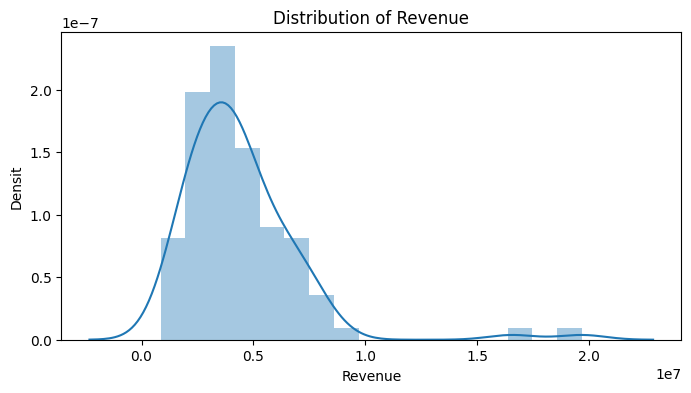

In [22]:
plt.figure(figsize = (8, 4))

sns.distplot(df['Revenue'])

plt.xlabel("Revenue")
plt.ylabel('Densit')
plt.title("Distribution of Revenue")

plt.show()

**Revenue Distribution :**

- The distribution of the Revenue variable is positively skewed (right-skewed). This indicates that while most restaurants generate moderate revenue, a small number of restaurants generate significantly higher revenue, resulting in a long tail on the right side of the distribution. This also suggests the presence of high-revenue outliers in the dataset.
****

**Chart 2: Average Revenue Generated by Restaurants**

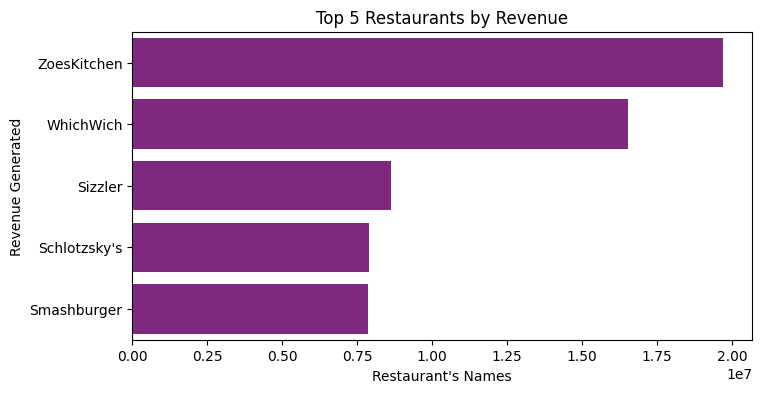

In [23]:
# Top 5 restaurants by revenue
Restaurants_and_Revenue = df[['Name', 'Revenue']]

top_5_restaurants = df.sort_values(by = 'Revenue', ascending = False).head(5)

# Horizontal Bar Plot
plt.figure(figsize = (8, 4))

ax = sns.barplot(
    x = 'Revenue',
    y = 'Name',
    data = top_5_restaurants,
    color = 'purple',
    alpha = 0.9
)

plt.xlabel("Restaurant's Names")
plt.ylabel("Revenue Generated")
plt.title("Top 5 Restaurants by Revenue")

plt.show()

**Top 5 Highest Revenue-Generating Restaurants :**

The analysis of restaurant-level revenue shows that the top five revenue-generating restaurants in the dataset are:

- ZoesKitchen
- WhichWich
- Sizzler
- Schlotzsky's
- Smashburger

These restaurants significantly outperform others in terms of revenue, which may indicate strong customer demand, effective operations, or popular menu offerings.
****

In [24]:
# Range of revenue 
min = df['Revenue'].min()

max = df['Revenue'].max()

range = max - min

print(range)

18847069


**Chart 3 : Distribution of Orders Placed**

Text(0.5, 1.0, 'Distribution of Orders Placed')

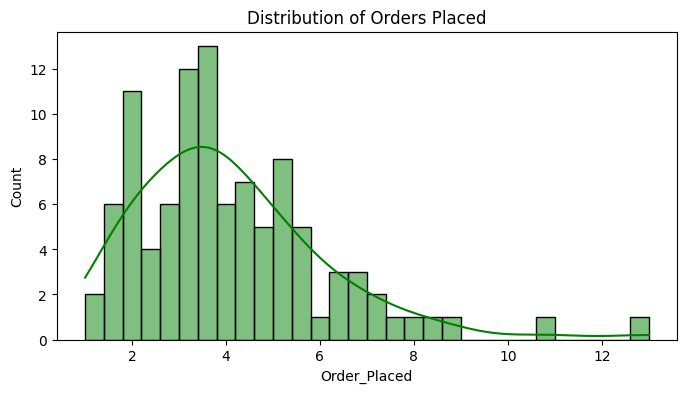

In [25]:
plt.figure(figsize = (8, 4))

sns.histplot(df['Order_Placed'], bins = 30, color = 'green', edgecolor = 'k', kde = True)

plt.title("Distribution of Orders Placed")

**Order Volume Distribution :**

The Orders Placed variable also exhibits a right-skewed distribution. This suggests that most restaurants receive a moderate number of orders, while a few restaurants receive very high order volumes, which likely contributes to higher revenue generation.
****

**Chart 4 : Top 5 categories with highest revenue**

In [26]:
top_5_categories_with_highest_revenue = df[['Category', 'Revenue']]

# Sort the values in descending order(Categories with Highest revenue comes first)
top_5_categories_with_highest_revenue = top_5_categories_with_highest_revenue.sort_values(by = 'Revenue', ascending = False)

# Extract Top 5 Categories
top_5_categories = top_5_categories_with_highest_revenue.head()

Visualizing Top 5 Categories with Highest Revenue generated

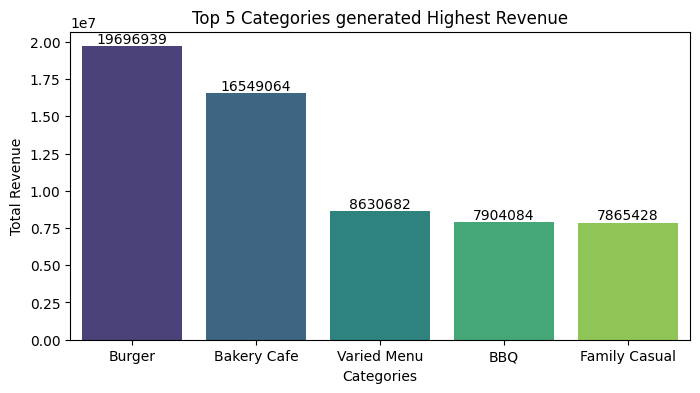

In [27]:
plt.figure(figsize = (8, 4))

ax = sns.barplot(x = 'Category', y = 'Revenue', palette = 'viridis', data = top_5_categories)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2, 
                 p.get_height()),
                 ha = 'center', va = 'bottom')

plt.xlabel("Categories")
plt.ylabel("Total Revenue")
plt.title("Top 5 Categories generated Highest Revenue")

plt.show()

**Categories Generating Highest Revenue :**

From the category-level analysis, the following restaurant categories generate the highest total revenue:

- Burger
- Bakery Cafe
- Varied Menu Categories
- BBQ
- Family Casual

These categories appear to have strong customer demand and higher sales performance, which may make them attractive for restaurant business expansion.
****

**Chart 5: Categories with Lowest Revenue**

In [28]:
top_5_categories_with_highest_revenue = df[['Category', 'Revenue']]

# Sort the values in descending order(Categories with Lowest revenue comes first)
top_5_categories_with_highest_revenue = top_5_categories_with_highest_revenue.sort_values(by = 'Revenue', ascending = True)

# Extract Top 5 Categories
top_5_categories = top_5_categories_with_highest_revenue.head()

Visualizing the Categories with Lowest Revenue

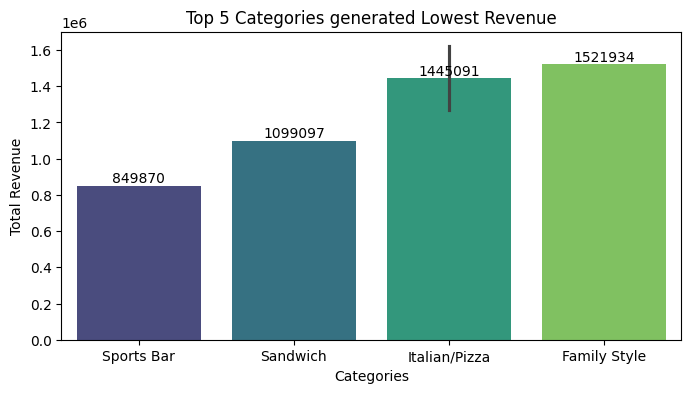

In [59]:
plt.figure(figsize = (8, 4))

ax = sns.barplot(x = 'Category', y = 'Revenue', palette = 'viridis', data = top_5_categories)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2, 
                 p.get_height()),
                 ha = 'center', va = 'bottom')

plt.xlabel("Categories")
plt.ylabel("Total Revenue")
plt.title("Top 5 Categories generated Lowest Revenue")

plt.show()

**Categories Generating Lowest Revenue :**

Some categories generate comparatively lower revenue, including:

- Sports Bar
- Sandwich
- Italian/Pizza
- Family Style

This could indicate lower demand, niche customer segments, or fewer restaurants operating in these categories within the dataset.
****

**Chart 6 : Bivariate Analysis : Relationship between number of menu items and revenue**

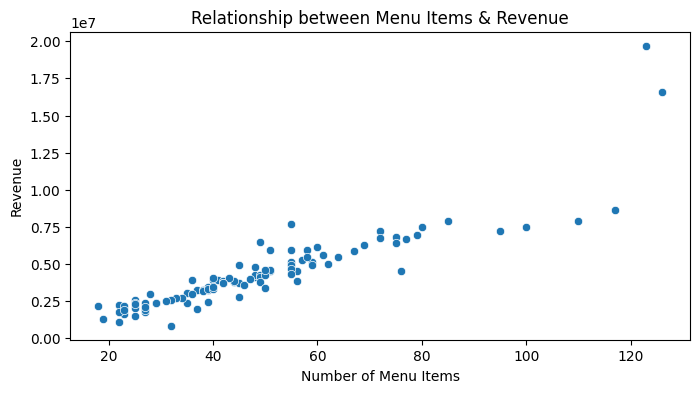

In [30]:
plt.figure(figsize = (8, 4))

sns.scatterplot(x = 'No_Of_Item', y = 'Revenue', data = df)

plt.xlabel("Number of Menu Items")
plt.ylabel("Revenue")
plt.title("Relationship between Menu Items & Revenue")

plt.show()

**Relationship Between Menu Size and Revenue :**

The scatter plot analysis between Number of Menu Items and Revenue indicates a positive relationship. Restaurants offering a larger variety of menu items tend to generate higher revenue, possibly because a broader menu can attract a wider range of customer preferences.
****

**Chart 7 : Relationship between Orders Placed vs Revenue**

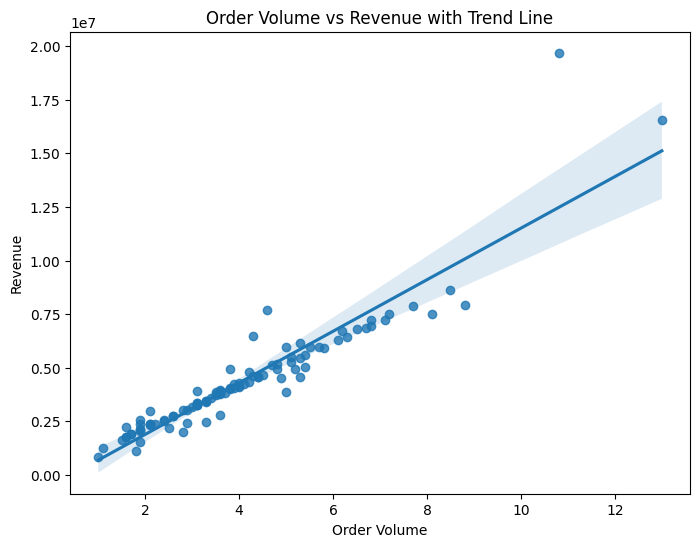

In [31]:
plt.figure(figsize=(8,6))

sns.regplot(x='Order_Placed', y='Revenue', data=df)

plt.xlabel("Order Volume")
plt.ylabel("Revenue")
plt.title("Order Volume vs Revenue with Trend Line")

plt.show()

**Relationship Between Orders and Revenue :**

The analysis also shows a strong positive relationship between the number of orders placed and revenue generated. Restaurants that receive a higher number of orders naturally generate higher revenue, as revenue is directly influenced by the volume of customer transactions.
****

**Chart 8: Correlation Analysis**

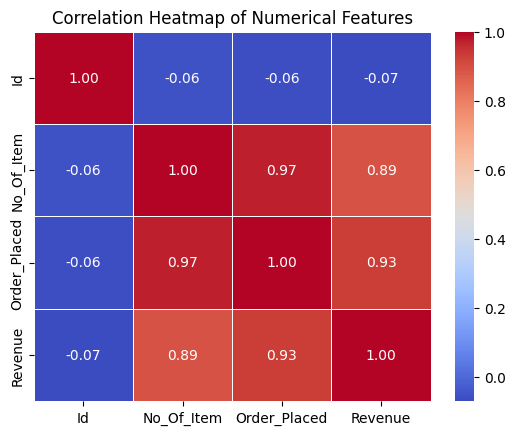

In [32]:
# Grab All numerical columns
numerical_cols = df.select_dtypes(include = 'number')

corr = numerical_cols.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

**Observation :**

- Correlation between "Id" & "Number of Item" is -0.06, between "id" and "Revenue" is -0.07.

- Correlation Between Number of item and Order Placed is ~0.97 and Correlation between Number of item and Revenue is ~0.89.

- Correlation between Order Placed and Revenue is ~0.93.

**Outlier Detection**

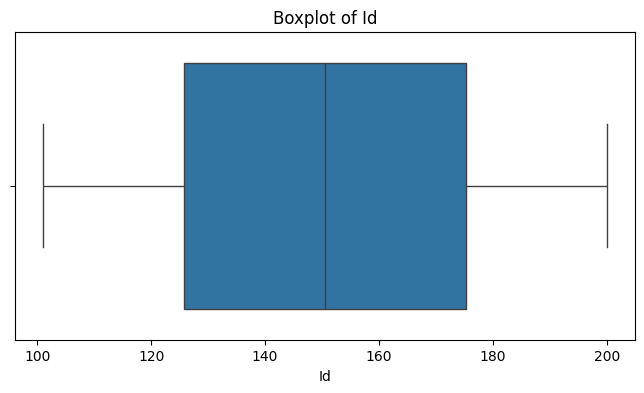

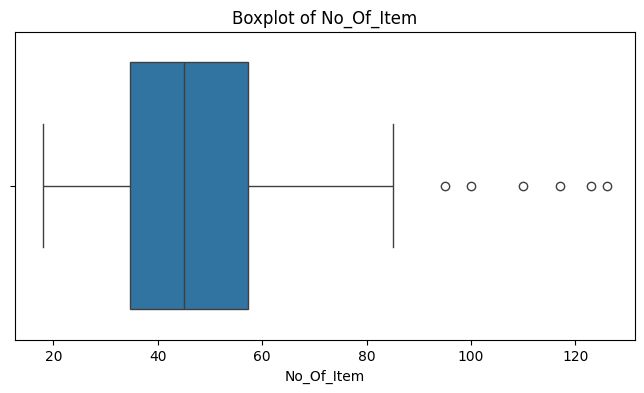

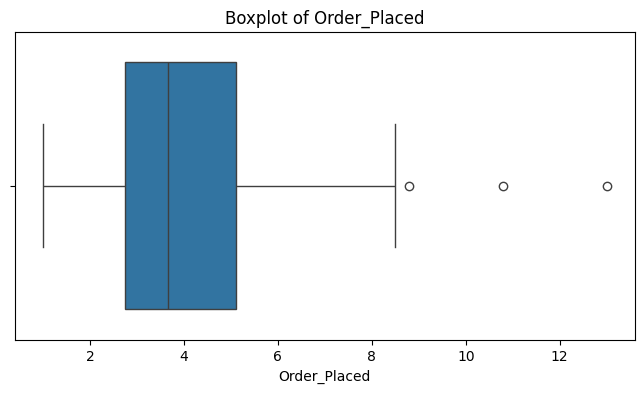

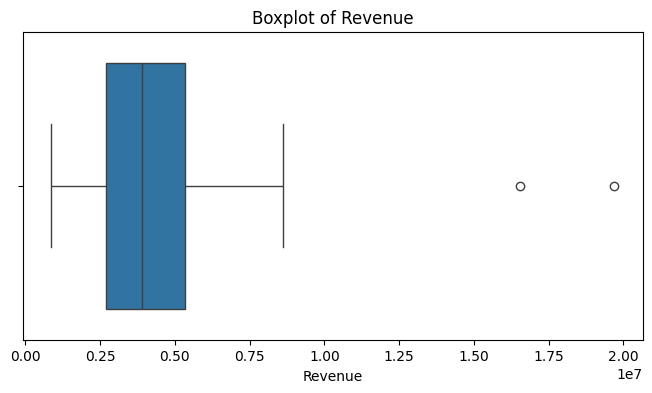

In [33]:
# Grab all numerical cols
num_cols = df.select_dtypes(include = 'number')

for col in num_cols:
    plt.figure(figsize = (8, 4))
    sns.boxplot(x = df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Observations :**

Columns Number of Items, Order Placed and revenue has outliers in it, but we will not remove these outliers because the number of outliers are not very huge and also we have very small dataset.

In [34]:
df.head()

,Id,Name,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,101,HungryHowie'sPizza,Yes,Mexican,Bengaluru,55,5.5,5953753
1,102,CharleysPhillySteaks,No,Varied Menu,Gurugram,72,6.8,7223131
2,103,Chuy's,Yes,Chicken,Pune,25,1.9,2555379
3,104,O'Charley's,Yes,Italian/Pizza,Mumbai,18,2.5,2175511
4,105,PolloTropical,Yes,Pizza,Noida,48,4.2,4816715


We will drop the Columns "Id" and "Name" as they do not contribute anything to the Model Prediction.

In [35]:
# Drop Columns "Id" & "Name"
df.drop(columns = ['Id', 'Name'], axis = 1, inplace = True)

In [36]:
# Columns we have
df.columns

Index(['Franchise', 'Category', 'City', 'No_Of_Item', 'Order_Placed',
       'Revenue'],
      dtype='object')

#### 6. Label Encoding

In [37]:
# Display Only Categorical Columns
df.select_dtypes(include = 'object')

,Franchise,Category,City
0,Yes,Mexican,Bengaluru
1,No,Varied Menu,Gurugram
2,Yes,Chicken,Pune
3,Yes,Italian/Pizza,Mumbai
4,Yes,Pizza,Noida
...,...,...,...
95,No,Italian/Pizza,Bengaluru
96,Yes,Varied Menu,Bengaluru
97,Yes,Varied Menu,Gurugram
98,Yes,Sports Bar,Pune


In [38]:
# Value counts of Franchise
df['Franchise'].value_counts()

Franchise
Yes    55
No     45
Name: count, dtype: int64

In [39]:
df['City'].value_counts()

City
Bengaluru    43
Mumbai       19
Noida        18
Pune         13
Gurugram      7
Name: count, dtype: int64

In [40]:
df['Category'].value_counts()

Category
Varied Menu        16
Mexican            10
Pizza               9
Italian/Pizza       7
Family Style        7
Steak               7
Sandwich            7
Burger              7
Bakery Cafe         5
BBQ                 4
Seafood             4
Family Casual       3
Chicken             2
Frozen Desserts     2
Coffee Cafe         2
Sports Bar          2
Snack               2
Asian/Noodle        2
Asian               1
Healthy             1
Name: count, dtype: int64

We will encoder "City", "Franchise" & "City" Columns Using Label Encoder.

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Perform LabelEncoding
df['Franchise'] = le.fit_transform(df['Franchise'])
df['City'] = le.fit_transform(df['City'])
df['Category'] = le.fit_transform(df['Category'])

In [42]:
# Value counts of City
df['City'].value_counts()

City
0    43
2    19
3    18
4    13
1     7
Name: count, dtype: int64

In [43]:
# Check data
df['Franchise'].value_counts()

Franchise
1    55
0    45
Name: count, dtype: int64

In [44]:
df['Category'].value_counts()

Category
19    16
12    10
13     9
11     7
8      7
18     7
14     7
4      7
3      5
2      4
15     4
7      3
5      2
9      2
6      2
17     2
16     2
1      2
0      1
10     1
Name: count, dtype: int64

**Note :**

- In Column Franchise, 0 refers to No and 1 refers to Yes. In City Column, 0 refers to Bengaluru, 1 refers to Gurugram, 2 refers to Mumbai, 3 refers to Noida, 4 refers to Pune.

In [45]:
# Check data
df.head(10)

,Franchise,Category,City,No_Of_Item,Order_Placed,Revenue
0,1,12,0,55,5.5,5953753
1,0,19,1,72,6.8,7223131
2,1,5,4,25,1.9,2555379
3,1,11,2,18,2.5,2175511
4,1,13,3,48,4.2,4816715
5,1,15,3,56,4.9,4517319
6,1,18,3,58,5.0,5966635
7,1,13,2,49,4.3,6491607
8,1,12,2,59,4.8,5152497
9,1,18,4,76,5.3,4544227


In [46]:
df.columns

Index(['Franchise', 'Category', 'City', 'No_Of_Item', 'Order_Placed',
       'Revenue'],
      dtype='object')

#### 7. Model Building & Model Evaluation

**Simple Linear Regression**

In [47]:
# Divide the data into x and y variables
x = df.drop(["Revenue", 'Franchise', 'Category', 'City', 'No_Of_Item'], axis = 1)
y = df['Revenue']

**Split the dataset into Training set and Test set**

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [49]:
print(x_train.shape)

(80, 1)


In [50]:
print(y_train.shape)

(80,)


**Training the Simple Linear Regression model on the Training set**

In [51]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Predicting the Test set results**

In [52]:
y_pred = regressor.predict(x_test)

In [53]:
y_pred

array([6351103.23642517, 5984998.65773576, 4032440.90472562,
       3788371.18559935, 4276510.62385189, 3910406.04516249,
       4032440.90472562, 3666336.32603622, 3788371.18559935,
       6107033.5172989 , 5740928.9386095 , 2934127.16865742,
       3178196.88778369, 2079883.15171548, 3422266.60690995,
       4520580.34297816, 4642615.20254129, 1469708.85389981,
       1347673.99433668, 1713778.57302608])

**Visualising the Training set results**

Text(0, 0.5, 'Revenue')

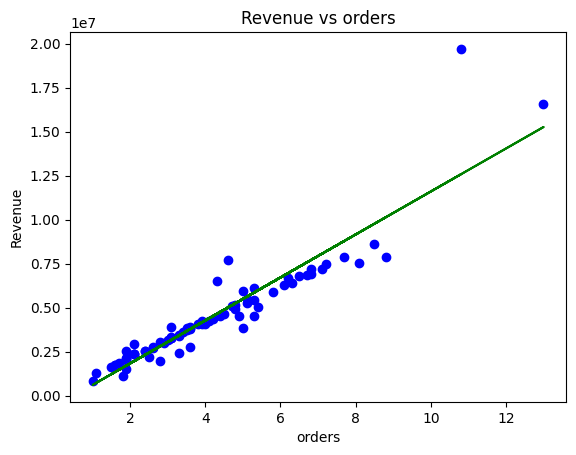

In [54]:
plt.scatter(x_train,y_train,color="blue")
plt.plot(x_train,regressor.predict(x_train),color="green")
plt.title("Revenue vs orders")
plt.xlabel("orders")
plt.ylabel("Revenue")

**Visualising the Test set results**

Text(0, 0.5, 'Revenue')

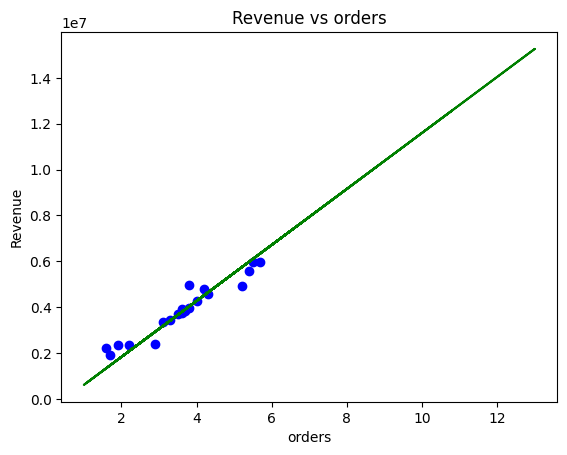

In [55]:
plt.scatter(x_test,y_test,color="blue")
plt.plot(x_train,regressor.predict(x_train),color="green")
plt.title("Revenue vs orders")
plt.xlabel("orders")
plt.ylabel("Revenue")

**Accuracy of the Model**

In [56]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

**Linear Regression Model Evaluation**

In [57]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
lr_r2 = r2_score(y_pred, y_test)

print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"R2 Score : {lr_r2}")

MAE : 318430.6326798172
MSE : 186768572957.39304
RMSE : 432167.2974177859
R2 Score : 0.9109612329066813


#### 8. Compare Actual Vs Predicted Revenue

Table of Actual, Predicted and Error

In [ ]:
comparison = pd.DataFrame({
    "Actual Revenue": y_test,
    "Predicted Revenue": y_pred
})

print(comparison.head(10))

    Actual Revenue  Predicted Revenue
83         5966193       6.351103e+06
53         5595267       5.984999e+06
70         3982767       4.032441e+06
45         3752885       3.788371e+06
44         4264176       4.276511e+06
39         3818055       3.910406e+06
22         4956086       4.032441e+06
80         3727364       3.666336e+06
10         3945135       3.788371e+06
0          5953753       6.107034e+06


In [ ]:
# Difference between Actual Revenue and Predicted Revenue

comparison["Error"] = comparison["Actual Revenue"] - comparison["Predicted Revenue"]

print(comparison.head(10))

    Actual Revenue  Predicted Revenue          Error
83         5966193       6.351103e+06 -384910.236425
53         5595267       5.984999e+06 -389731.657736
70         3982767       4.032441e+06  -49673.904726
45         3752885       3.788371e+06  -35486.185599
44         4264176       4.276511e+06  -12334.623852
39         3818055       3.910406e+06  -92351.045162
22         4956086       4.032441e+06  923645.095274
80         3727364       3.666336e+06   61027.673964
10         3945135       3.788371e+06  156763.814401
0          5953753       6.107034e+06 -153280.517299


Plot Residuals (Residual = Actual - Predicted)

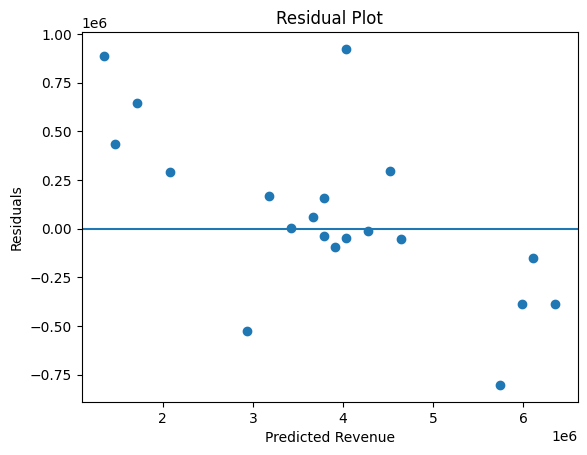

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

**Note :**

- After Plotting the residual for actual and predicted value, we see that errors are centered around 0 this indicates our model is good.

Visualizing Actual Revenue & Predicted Revenue Using Line Plot.

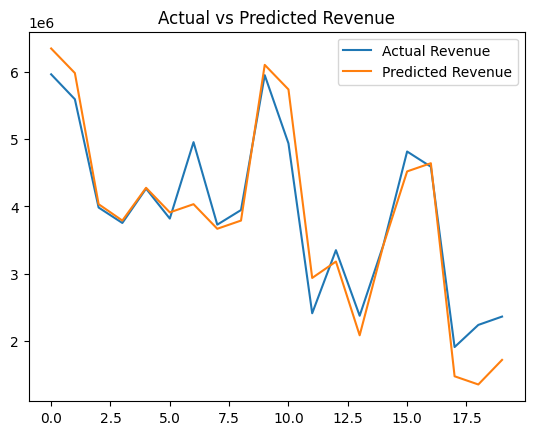

In [ ]:
plt.plot(y_test.values, label="Actual Revenue")
plt.plot(y_pred, label="Predicted Revenue")

plt.legend()

plt.title("Actual vs Predicted Revenue")

plt.show()

**Note :**

- As we see the the actual revenue line and predicted revenue line plots are overlapping each other which indicates the predicted revenue is quite close to the actual revenue and they are quite similar, but there are still gaps in it. So we will try building random foretst regressor model.

**Random Forest Regressor for Restaurant Revenue Prediction**

In [ ]:
# Import necessary libraries

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# Split the data into x and y
X = df.drop(['Revenue', 'Category', 'City', 'No_Of_Item', 'Franchise'], axis = 1)
y = df['Revenue']

In [ ]:
X

,Order_Placed
0,5.5
1,6.8
2,1.9
3,2.5
4,4.2
...,...
95,1.1
96,6.3
97,6.2
98,2.1


We will built Random Forest Regressor Revenue Prediction Model using columns like 'Category', 'Franchise', 'City', 'No of Item', 'Order Placed'.

In [ ]:
# Divide into Training and Testings sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
# Create the Model
rfr_model = RandomForestRegressor(
    n_estimators = 100,
    random_state = 42
)

In [ ]:
# Train the model
rfr_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Make Predictions
y_pred = rfr_model.predict(X_test)
y_pred

array([5679295.73816667, 5207132.27166667, 4066785.67716667,
       3597989.77174423, 4129611.21766667, 3861909.84014683,
       4066785.67716667, 3773651.67683333, 3597989.77174423,
       5216821.609     , 5376596.53283333, 2998867.687     ,
       3398501.10119444, 2500532.68961905, 3114563.87942857,
       4518108.90433333, 5889851.85333333, 1635935.08404762,
       1735536.40938095, 2075954.41092063])

**Evaluate the Model**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae}")
print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"R2 Score : {r2}")

MAE : 364108.4156430374
MSE : 228884537147.1744
RMSE : 478418.7884554435
R2 Score : 0.8436855069974248


**Check Actual Revenue Vs Predicted Revenue**

In [ ]:
comparison = pd.DataFrame({
    "Actual Revenue" : y_test.values,
    "Predicted Revenue" : y_pred
})

comparison.head(10)

,Actual Revenue,Predicted Revenue
0,5966193,5.679296e+06
1,5595267,5.207132e+06
2,3982767,4.066786e+06
3,3752885,3.597990e+06
4,4264176,4.129611e+06
5,3818055,3.861910e+06
6,4956086,4.066786e+06
7,3727364,3.773652e+06
8,3945135,3.597990e+06
9,5953753,5.216822e+06


Plot the Actual Revenue Vs Predicted Revenue

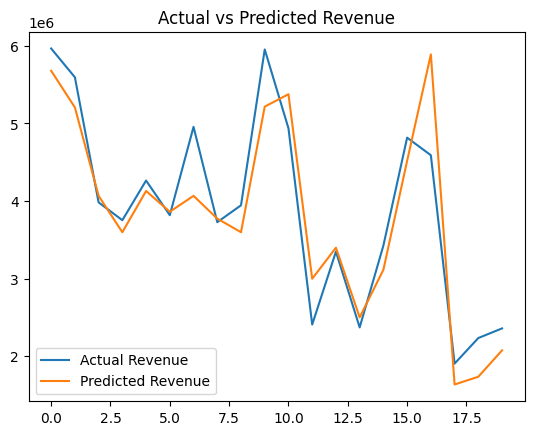

In [ ]:
plt.plot(y_test.values, label="Actual Revenue")
plt.plot(y_pred, label="Predicted Revenue")

plt.legend()

plt.title("Actual vs Predicted Revenue")

plt.show()

**SUMMAR / REPORT OF THE PROJECT :**

**A. Key Insights from Exploratory Data Analysis(EDA) :**

- The top five revenue-generating restaurants in the dataset are: "ZoesKitchen" , "Whichwich", "Sizzler", "Schlotzsky's", "Smashburger".

- The following restaurant categories generate the highest total revenue: "Burger", "Bakery Cafe", "Varied Menu Categories", "BBQ", "Family Casual".

- Some categories generate comparatively lower revenue, including: "Sports Bar", "Sandwich", "Italian/Pizza", "Family Style".

**B. Model Building and Evaluation :**

**Baseline Model - Simple Linear Regression :**

- To establish a baseline, a Simple Linear Regression model was developed using Order Placed as the Independent variable and Revenue as the Target Variable.

- Model was evaluated using standard regression evaluation metrics like R2 Score ~ 0.91%, Mean Absolute Error(MAE) ~318,430, Mean Squared Error(MSE) ~186,768,572,957, Root Mean Squared Error(RMSE) ~432,167. The high R2 Score(~0.91%) indicates that the model explains approximately 91% of the variance in Revenue, suggesting strong relationship between the number of orers placed and the revenue generated.

*Prediction Analysis :*

To further evaluate the model performance: 

- A comparison dataframe was created containing Actual Revenue and Predicted Revenue.

- The prediction error was calculated as: 𝐸𝑟𝑟𝑜𝑟 = 𝐴𝑐𝑡𝑢𝑎𝑙 𝑅𝑒𝑣𝑒𝑛𝑢𝑒 − 𝑃𝑟𝑒𝑑𝑖𝑐𝑡𝑒𝑑 𝑅𝑒𝑣𝑒𝑛𝑢𝑒

- The top observations were examined to understand the prediction differences.

*Residual Analysis :*

- Residual errors were computed as: 𝑅𝑒𝑠𝑖𝑑𝑢𝑎𝑙 = 𝐴𝑐𝑡𝑢𝑎𝑙 𝑅𝑒𝑣𝑒𝑛𝑢𝑒 − 𝑃𝑟𝑒𝑑𝑖𝑐𝑡𝑒𝑑 𝑅𝑒𝑣𝑒𝑛𝑢𝑒

- A scatter plot of residuals was created, which showed that the errors were distributed around zero without a clear pattern. This indicates that the model predictions are reasonably accurate and that the model does not exhibit significant bias.

*Visualization :*

- The relationship between actual revenue and predicted revenue was visualized using a line plot, which showed that the predicted values closely follow the actual revenue values.

**2. Random Forest Regressor Model :**

1. To explore a more advanced machine learning approach, a Random Forest Regressor model was implemented using the same input feature (Order Placed) to predict restaurant revenue. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

2. The model was configured with:
- Number of trees (n_estimators): 100
- Random state: 42 (to ensure reproducibility)

3. The model was trained on the training dataset and evaluated on the testing dataset.

*Model Performance :*
- The Random Forest model achieved the following results: R² Score: ~0.84, Mean Absolute Error (MAE): ~364,108 Mean Squared Error (MSE): ~228,884,537,147, Root Mean Squared Error (RMSE): ~478,418.

- Although the Random Forest model is generally more powerful, in this case the Simple Linear Regression model performed slightly better, likely because the relationship between orders placed and revenue is largely linear.

*Prediction Comparison :*

A comparison dataframe was created to analyze: Actual Revenue, Predicted Revenue, Prediction Error. This helped evaluate how closely the predicted values matched the actual revenue.

*Visualization :*

A line plot comparing actual revenue vs predicted revenue was created to visually assess the model's predictive performance. The visualization confirmed that the model captures the general revenue trend, though with slightly larger deviations compared to the linear regression model.


**Key Observation**

The Simple Linear Regression model outperformed the Random Forest model for this dataset. This suggests that the relationship between orders placed and revenue is strongly linear, making a simple regression model sufficient for accurate predictions.

**Final Conclusion**

- The analysis shows that order volume is a strong predictor of restaurant revenue. The baseline linear regression model was able to capture this relationship effectively, achieving a high R² score and relatively low prediction errors.

- Although a Random Forest model was also implemented to explore non-linear relationships, the linear model performed better in this case. This highlights the importance of starting with simple models before applying more complex algorithms.

- These findings demonstrate that order volume plays a critical role in revenue generation, and the developed models can be used to estimate revenue based on restaurant order activity.

- Choosing the Linear Regression Model as the final model for deployment due to its better performance.

**BUSINESS RECOMMENDATIONS :**

**1. Focus on Increasing Order Volume :** 

The analysis revealed a strong positive relationship between the number of orders placed and revenue generated. Restaurants receiving a higher number of orders tend to generate significantly more revenue.

*Recommendation:*

Restaurant businesses should focus on strategies that increase order volume, such as:

- Online food delivery partnerships
- Promotional campaigns and discounts
- Loyalty programs and customer retention strategies
- Improving service efficiency to handle higher order volumes

Increasing order volume is likely to have the most direct impact on revenue growth.
****

**2. Expand Menu Variety Strategically :** 

The analysis also showed a positive relationship between the number of menu items and restaurant revenue. Restaurants offering a broader selection of menu items tend to attract more customers.

*Recommendation :*

Restaurants should consider expanding their menu offerings while ensuring:

- Menu items align with customer preferences
- Kitchen operations remain efficient
- Quality and consistency of food are maintained

A well-balanced menu variety can attract a wider customer base and increase sales opportunities.
****

**3. Use Predictive Models for Revenue Forecasting :** 

The machine learning models developed in this project can help restaurants predict future revenue based on operational factors such as order volume and menu size.

*Recommendation :*

- Restaurant management can use predictive analytics to: 
    - Forecast revenue trends
    - Plan staffing and inventory requirements
    - Optimize marketing campaigns
    - Support data-driven business decisions

Using predictive insights can help businesses reduce uncertainty and improve financial planning.